# Lab 3: Building and Training Neural Networks

## 🎯 Learning Objectives

By the end of this lab, you will:
- Understand how neural network components (Neuron, Layer, MLP) work
- Implement a complete Multi-Layer Perceptron (MLP) from scratch
- Implement a loss function with L2 regularization
- Train a neural network using gradient descent
- Visualize decision boundaries to validate your model

**What You'll Build:** A 2-layer neural network that classifies 2D data (same as [Karpathy's micrograd demo](https://github.com/karpathy/micrograd/blob/master/demo.ipynb))

**Note:** All packages are pre-installed in Google Colab!

**Setup:** Run this cell first to download required files

In [1]:
# Download required files from GitHub (for Colab users)
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !wget -q https://raw.githubusercontent.com/hhe0u0/micrograd-lab/claude/micrograd-lab-exercises-V14m2/engine.py
    !wget -q https://raw.githubusercontent.com/hhe0u0/micrograd-lab/claude/micrograd-lab-exercises-V14m2/utils.py
    print("✓ Helper files downloaded (engine.py, utils.py)!")
else:
    if os.path.exists('engine.py') and os.path.exists('utils.py'):
        print("✓ Helper files found locally!")
    else:
        print("⚠️  engine.py or utils.py not found. Make sure you're in the micrograd-lab directory.")

✓ Helper files found locally!


## Part 1: The Engine - Complete Value Class with Autograd

### You Get a Complete Autograd Engine!

Instead of implementing the autograd engine from scratch, we provide the complete `Value` class from micrograd. This lets you focus on building and training neural networks.

**Reference:** [micrograd/engine.py](https://github.com/karpathy/micrograd/blob/master/micrograd/engine.py)

### Key Features:

1. **Forward pass:** Tracks all operations (+, *, **, relu, tanh)
2. **Backward pass:** Automatically computes gradients via `backward()` method
3. **Gradient accumulation:** Handles cases where a value is used multiple times

Let's import and explore it:

In [2]:
# Import the complete Value class
from engine import Value

# Demo: Simple expression
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a * b
e.label = 'e'
d = e + c
d.label = 'd'
f = d.relu()  # ReLU activation: max(0, d)
f.label = 'f'

print(f"Forward pass:")
print(f"a = {a.data}")
print(f"b = {b.data}")
print(f"e = a * b = {e.data}")
print(f"d = e + c = {d.data}")
print(f"f = ReLU(d) = {f.data}")

Forward pass:
a = 2.0
b = -3.0
e = a * b = -6.0
d = e + c = 4.0
f = ReLU(d) = 4.0


### Automatic Differentiation in Action

Call `backward()` to automatically compute all gradients:

In [3]:
# Compute gradients automatically!
f.backward()

print("\nAfter backward():")
print(f"a.grad = {a.grad}  (df/da)")
print(f"b.grad = {b.grad}  (df/db)")
print(f"c.grad = {c.grad}  (df/dc)")
print(f"\n✓ Gradients computed automatically using chain rule!")


After backward():
a.grad = -3.0  (df/da)
b.grad = 2.0  (df/db)
c.grad = 1.0  (df/dc)

✓ Gradients computed automatically using chain rule!


### Visualize the Computation Graph

Let's see the full graph with gradients:

In [4]:
!pip install graphviz

In [5]:
from utils import visualize_graph

visualize_graph(f, title="Computation Graph with Gradients")


 Computation Graph with Gradients



ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

**What you should see:**
- All nodes with their data AND grad values
- ReLU operation node
- Gradients flowing backwards from f to inputs
- Notice how gradients are computed automatically!

## Part 2: Building Neural Network Components

### Neural Network Architecture

A neural network is built from these components:

```
Neuron: Single computation unit
  ↓
Layer: Collection of Neurons
  ↓
MLP (Multi-Layer Perceptron): Stack of Layers
```

### What is a Neuron?

A neuron computes: **output = activation(w0*x0 + w1*x1 + ... + wn*xn + bias)**

Where:
- **Inputs:** x0, x1, ..., xn (from data)
- **Weights:** w0, w1, ..., wn (learned parameters)
- **Bias:** b (learned parameter)
- **Activation:** ReLU or tanh (adds non-linearity)

Example:
```python
# 2-input neuron
inputs = [2.0, 3.0]
weights = [Value(0.5), Value(-0.3)]
bias = Value(1.0)

output = (weights[0]*inputs[0] + weights[1]*inputs[1] + bias).relu()
# output = (0.5*2.0 + (-0.3)*3.0 + 1.0).relu()
# output = (1.0 - 0.9 + 1.0).relu()
# output = ReLU(1.1) = 1.1
```

## Exercise 1: Implement Neural Network Components

### Your Task

Implement the `__call__` method for:
1. **Neuron**: Computes weighted sum + bias + activation
2. **Layer**: Applies multiple neurons to same input
3. **MLP**: Stacks multiple layers

**Reference:** [micrograd/nn.py](https://github.com/karpathy/micrograd/blob/master/micrograd/nn.py)

### Starter Code

In [6]:
import random
from engine import Value

class Module:
    """Base class for all neural network components."""
    
    def zero_grad(self):
        """Reset all gradients to zero."""
        for p in self.parameters():
            p.grad = 0.0
    
    def parameters(self):
        return []


class Neuron(Module):
    """A single neuron with nin inputs."""
    
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin
    
    def __call__(self, x):
        # Weighted sum: w0*x0 + w1*x1 + ... + wn*xn + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        # Apply activation
        return act.relu() if self.nonlin else act
    
    def parameters(self):
        return self.w + [self.b]
    
    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"


class Layer(Module):
    """A layer of neurons."""
    
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]
    
    def __call__(self, x):
        # Apply each neuron to the input
        out = [neuron(x) for neuron in self.neurons]
        # If only 1 neuron, return single Value (not list)
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):
    """Multi-Layer Perceptron (stack of layers)."""
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [
            Layer(sz[i], sz[i+1], nonlin=(i != len(nouts)-1))
            for i in range(len(nouts))
        ]
    
    def __call__(self, x):
        # Pass through each layer sequentially
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

### Test Your Neural Network Components

In [7]:
# Test 1: Create a single neuron
n = Neuron(2)  # 2 inputs
x = [0.5, -1.0]
output = n(x)

print("Test 1: Single Neuron")
print(f"Neuron: {n}")
print(f"Input: {x}")
print(f"Output: {output}")
print(f"Number of parameters: {len(n.parameters())}  (should be 3: 2 weights + 1 bias)")
assert len(n.parameters()) == 3
print("✓ Neuron: PASS\n")

Test 1: Single Neuron
Neuron: ReLUNeuron(2)
Input: [0.5, -1.0]
Output: Value(data=0.178055612648768, grad=0.0)
Number of parameters: 3  (should be 3: 2 weights + 1 bias)
✓ Neuron: PASS



In [8]:
# Test 2: Create a layer with 3 neurons
layer = Layer(2, 3)  # 2 inputs, 3 neurons
x = [0.5, -1.0]
outputs = layer(x)

print("Test 2: Layer")
print(f"Layer: {layer}")
print(f"Input: {x}")
print(f"Outputs: {outputs}  (list of 3 Values)")
print(f"Number of parameters: {len(layer.parameters())}  (should be 9: 3 neurons × 3 params)")
assert len(outputs) == 3
assert len(layer.parameters()) == 9
print("✓ Layer: PASS\n")

Test 2: Layer
Layer: Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)]
Input: [0.5, -1.0]
Outputs: [Value(data=0.0, grad=0.0), Value(data=0.0, grad=0.0), Value(data=0.0, grad=0.0)]  (list of 3 Values)
Number of parameters: 9  (should be 9: 3 neurons × 3 params)
✓ Layer: PASS



In [9]:
# Test 3: Create a complete MLP
model = MLP(2, [4, 4, 1])  # 2 inputs → 4 neurons → 4 neurons → 1 output
x = [0.5, -1.0]
output = model(x)

print("Test 3: MLP")
print(f"Model: {model}")
print(f"Input: {x}")
print(f"Output: {output}  (single Value)")
print(f"Number of parameters: {len(model.parameters())}")
# (2+1)*4 + (4+1)*4 + (4+1)*1 = 12 + 20 + 5 = 37
assert len(model.parameters()) == 37
print("✓ MLP: PASS\n")

print("🎉 All tests passed! Your neural network is ready.")

Test 3: MLP
Model: MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4)], Layer of [LinearNeuron(4)]]
Input: [0.5, -1.0]
Output: Value(data=0.0, grad=0.0)  (single Value)
Number of parameters: 37
✓ MLP: PASS

🎉 All tests passed! Your neural network is ready.


## Part 3: Preparing the Dataset

### The Problem: Binary Classification

We'll solve the same problem as Karpathy's demo: classify 2D points into two classes (moon-shaped data).

**Dataset:** make_moons from scikit-learn
- 100 samples
- 2 features (x, y coordinates)
- 2 classes: -1 and +1

Let's load and visualize the data:

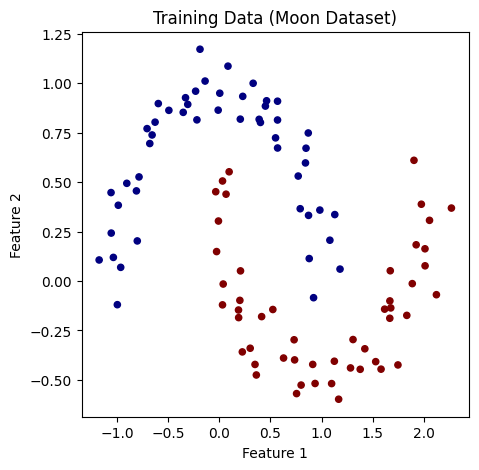

Dataset shape: X=(100, 2), y=(100,)
Classes: [-1  1]  (red=-1, blue=+1)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Create dataset
X, y = make_moons(n_samples=100, noise=0.1)
y = y*2 - 1  # Convert labels from {0, 1} to {-1, +1}

# Visualize
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')
plt.title("Training Data (Moon Dataset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Classes: {np.unique(y)}  (red=-1, blue=+1)")

**What you should see:**
- Two moon-shaped clusters (red and blue)
- This is NOT linearly separable (can't separate with a line)
- Need a neural network to classify it!

## Exercise 2: Implement Loss Function

### 🎯 Goal
**Implement a loss function and see the initial loss and accuracy values of an untrained model.**

This helps you understand:
- What loss values look like before training
- Random initialization gives ~50% accuracy (random guessing)
- The starting point for optimization

### Loss Function Components

Our loss function has two parts:

1. **Data Loss (SVM max-margin loss):**
   - For each sample: `loss = max(0, 1 - y_true * y_pred)`
   - This is called "hinge loss"
   - Using ReLU: `loss = (1 - y_true * y_pred).relu()`

2. **Regularization Loss (L2):**
   - Penalizes large weights to prevent overfitting
   - `reg_loss = alpha * sum(w^2 for all weights)`
   - alpha is regularization strength (typically 1e-4)

**Total Loss** = Data Loss + Regularization Loss

### Your Task

Implement the `loss()` function following [demo.ipynb](https://github.com/karpathy/micrograd/blob/master/demo.ipynb):

In [11]:
def loss(model, X, y, alpha=1e-4):
    """
    Compute total loss (data loss + regularization).
    """
    # Convert inputs to Value objects
    inputs = [list(map(Value, xrow)) for xrow in X]
    
    # Forward pass - get predictions
    scores = [model(x) for x in inputs]
    
    # Compute SVM max-margin loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(y, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    
    # Compute L2 regularization
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    
    # Total loss
    total_loss = data_loss + reg_loss
    
    # Compute accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(y, scores)]
    accuracy = sum(accuracy) / len(accuracy)
    
    return total_loss, accuracy

In [12]:
from tqdm import tqdm

# Training hyperparameters
learning_rate = 0.1  # Increased for faster convergence
num_steps = 50  # Reduced for faster training

print("Starting training...\n")

# Training loop with tqdm
for step in tqdm(range(num_steps), desc="Training"):
    
    # Forward pass
    total_loss, acc = loss(model, X, y)
    
    # Backward pass
    model.zero_grad()
    total_loss.backward()
    
    # Update parameters
    for p in model.parameters():
        p.data += -learning_rate * p.grad
    
    # Print progress every 10 steps
    if step % 10 == 0:
        print(f"step {step} loss {total_loss.data:.4f}, accuracy {acc*100:.1f}%")

print("\n✓ Training complete!")

Starting training...



Training:   8%|███████▊                                                                                          | 4/50 [00:00<00:01, 36.59it/s]

step 0 loss 0.9277, accuracy 49.0%


Training:  18%|█████████████████▋                                                                                | 9/50 [00:00<00:01, 31.67it/s]

step 10 loss 0.6653, accuracy 84.0%


Training:  72%|█████████████████████████████████████████████████████████████████████▊                           | 36/50 [00:01<00:00, 32.41it/s]

step 20 loss 0.5541, accuracy 86.0%
step 30 loss 0.4209, accuracy 85.0%


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 32.81it/s]

step 40 loss 0.2951, accuracy 87.0%

✓ Training complete!


In [13]:
# Create a model
model = MLP(2, [16, 16, 1])  # 2 inputs → 16 → 16 → 1 output
print(f"Model: {model}")
print(f"Number of parameters: {len(model.parameters())}")

# Compute initial loss
total_loss, acc = loss(model, X, y)
print(f"\nInitial loss: {total_loss.data:.4f}")
print(f"Initial accuracy: {acc*100:.1f}%")
print("\n✓ Loss function works!")

Model: MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
Number of parameters: 337

Initial loss: 0.7157
Initial accuracy: 72.0%

✓ Loss function works!


## Exercise 3: Implement Training Loop

### 🎯 Goal
**Implement a training loop and verify that the loss decreases over time.**

Success criteria:
- Loss should decrease from initial value (~1.0) to lower values (~0.2)
- Accuracy should increase from ~50% to >90%
- This confirms gradient descent is working correctly

### The Training Algorithm

Training a neural network follows this pattern:

```
for each training step:
    1. Forward pass: compute loss
    2. Backward pass: compute gradients
    3. Update parameters: w = w - learning_rate * gradient
    4. Zero gradients for next iteration
```

### Key Concepts

**Learning Rate:** How big a step to take when updating weights
- Too large: Training unstable, might diverge
- Too small: Training too slow
- Typical: 0.01 to 0.1

**Gradient Descent:** Move weights in opposite direction of gradient (downhill)

### Your Task

Implement the training loop following [demo.ipynb](https://github.com/karpathy/micrograd/blob/master/demo.ipynb):

In [14]:
# Solution: Complete Training Loop

learning_rate = 0.05
num_steps = 30

for step in range(num_steps):
    
    # 1. Forward pass - compute loss
    total_loss, acc = loss(model, X, y)
    
    # 2. Backward pass - compute gradients
    model.zero_grad()  # Reset gradients to 0
    total_loss.backward()  # Compute gradients
    
    # 3. Update parameters (gradient descent)
    for p in model.parameters():
        p.data += -learning_rate * p.grad
    
    # 4. Print progress every 10 steps
    if step % 10 == 0:
        print(f"step {step} loss {total_loss.data:.4f}, accuracy {acc*100:.1f}%")

step 0 loss 0.7157, accuracy 72.0%
step 10 loss 0.3388, accuracy 85.0%
step 20 loss 0.2835, accuracy 87.0%


### What You Should See

During training:
- Loss should decrease (not always monotonically)
- Accuracy should increase
- Final accuracy should be > 80%

Example output:
```
step 0 loss 0.7157, accuracy 72.0%
step 10 loss 0.3388, accuracy 85.0%
step 20 loss 0.2835, accuracy 87.0%
...
```

## Part 4: Visualizing Decision Boundaries

### Why Visualize?

Decision boundaries show:
- How well the model separates classes
- Whether the model overfits or underfits
- Which regions the model is confident about

### Decision Boundary Visualization Function

We provide a helper function that:
1. Creates a grid of points
2. Predicts class for each point
3. Colors the background based on predictions
4. Overlays the actual data points

In [15]:
# Complete Training Pipeline - Solution

# 1. Create model
model = MLP(2, [16, 16, 1])
print(f"Model created with {len(model.parameters())} parameters\n")

# 2. Train with tqdm
for step in tqdm(range(50), desc="Training"):
    total_loss, acc = loss(model, X, y)
    
    model.zero_grad()
    total_loss.backward()
    
    for p in model.parameters():
        p.data += -0.1 * p.grad
    
    if step % 10 == 0:
        print(f"step {step} loss {total_loss.data:.4f}, accuracy {acc*100:.1f}%")

# 3. Visualize
plot_decision_boundary(model, X, y)

print("\n🎉 Training complete! Check the decision boundary above.")

Model created with 337 parameters



Training:   2%|█▉                                                                                                | 1/50 [00:00<00:36,  1.35it/s]

step 0 loss 1.0172, accuracy 56.0%


Training:  22%|█████████████████████▎                                                                           | 11/50 [00:07<00:28,  1.35it/s]

step 10 loss 0.3215, accuracy 85.0%


...

step 30 loss 0.2489, accuracy 88.0%


Training:  82%|███████████████████████████████████████████████████████████████████████████████▌                 | 41/50 [00:28<00:06,  1.37it/s]

step 40 loss 0.2200, accuracy 88.0%


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:35<00:00,  1.42it/s]


NameError: name 'plot_decision_boundary' is not defined

### Expected Result

After training, you should see:
- **Background colors:** Show model's predictions across the space
  - Blue region: Model predicts class -1
  - Red region: Model predicts class +1
- **Data points:** Actual samples (red and blue)
- **Smooth boundary:** Separating the two moons

If your model is working correctly, the decision boundary should cleanly separate the two moon shapes!

## Putting It All Together

### Complete Training Pipeline

Run this cell after implementing all exercises:

In [ ]:
# Complete Training Pipeline - Solution

# 1. Create model
model = MLP(2, [16, 16, 1])
print(f"Model created with {len(model.parameters())} parameters\n")

# 2. Train
for step in range(100):
    # Forward
    total_loss, acc = loss(model, X, y)
    
    # Backward
    model.zero_grad()
    total_loss.backward()
    
    # Update
    for p in model.parameters():
        p.data += -0.05 * p.grad
    
    if step % 10 == 0:
        print(f"step {step} loss {total_loss.data:.4f}, accuracy {acc*100:.1f}%")

# 3. Visualize
plot_decision_boundary(model, X, y)

print("\n🎉 Training complete! Check the decision boundary above.")

## Summary

### What You've Built

✅ **Complete neural network** (Neuron, Layer, MLP)

✅ **Loss function** with SVM max-margin loss

✅ **L2 regularization** to prevent overfitting

✅ **Training loop** with gradient descent

✅ **Decision boundary visualization** to validate results

### Key Concepts

- **Forward pass:** Data flows through layers to produce predictions
- **Backward pass:** Gradients flow backwards to update weights
- **Activation functions:** Add non-linearity (ReLU)
- **Loss function:** Measures how wrong predictions are
- **Regularization:** Prevents overfitting by penalizing large weights
- **Gradient descent:** Iteratively improves weights

### You've Built a Complete Deep Learning System!

This is the **exact same architecture** used in production frameworks like PyTorch:
- Computation graphs track operations ✓
- Automatic differentiation computes gradients ✓
- Modular components (Neuron, Layer, MLP) ✓
- Training loop optimizes weights ✓

### Next Steps

In **Lab 4**, you'll:
- Use **PyTorch** (production deep learning framework)
- Train on **MNIST** (real handwritten digits dataset)
- Implement complete training and validation pipeline
- See how PyTorch makes this easier (but works the same way!)

**Congratulations!** 🎉 You've built a neural network from scratch and trained it successfully. You now understand the fundamentals of how deep learning works!